In [1]:
# Import all packages and relevant functions
import matplotlib.pyplot as plt
import numpy as np
import os
import dill as pickle
from sklearn.feature_selection import mutual_info_regression
from scipy.interpolate import make_smoothing_spline

# Import fns_plotting_scripts
import fns_plotting_scripts as fns_plot

In [3]:
# Define dataset and subset of conditions to be analyzed
mode_expt = 0

datadir = '/Users/idse/data_tmp/signaldecoding/'

if mode_expt == 1:
    directory = datadir + 'data_expt_X10_scaled_bgsub'
    conditions = ['B50']#['B10','B50','B200']
elif mode_expt == 2:
    directory = datadir + 'data_expt_X7_scaled_bgsub'
    conditions = ['B50']#, 'B50T30'
else:
    directory = datadir + 'data_expt_20_scaled_norm_bgsub'
    conditions = ['B50']
    use_scaled = 0 # this refers to Bassit's scaling of radial profiles from 0 to 1, scaled in the directory name is intensity compensation between colonies

# Define subdirectory to save plots to + take data from
subdirectory_plot = directory + '/analysis_poserror_intra'
if not os.path.exists(subdirectory_plot):
    os.mkdir(subdirectory_plot)
subdirectory_data = directory + '/data'


# Define parameters for figure plotting
file_suffix = '.png'
plt.close("all")

fig_size = [6,3]     
params = {
          'figure.figsize': fig_size,
          }
label_fontsize = 40
tick_fontsize = 35
cell_diam = 10 # cell diameter in microns
plt.rcParams.update(params)

plt.rcParams['axes.linewidth'] = 5
H,W = 1,3 #height and width of subplots
plt.rcParams['font.weight'] = 'normal'
weight = "normal"

# option for bold labels, ticks, and legends
is_bold = False
if is_bold:
    plt.rcParams['font.weight'] = 'bold'
    weight = "bold"

In [ ]:
# Idse, testing things

cond = 'B50';
f = open(subdirectory_data + '/data_' + cond + ".pickle",'rb')
data = pickle.load(f)
f.close()

In [ ]:
vars(data).keys()

In [56]:
data.gene_names

['ISL1',
 'GATA3',
 'HAND1',
 'CDX2',
 'TFAP2C',
 'SOX17',
 'PRDM1',
 'SNAI1',
 'MIXL1',
 'TBXT',
 'EOMES',
 'TBX6',
 'OCT4',
 'NANOG',
 'SOX2',
 'OTX2']

In [72]:
X=data.genes
pos_all=edge_dist
r_max=data.r_max
N_bins_x = 20
bins_x_raw, mean_x_raw, var_x_raw, pos_error_raw, P_x_raw, C_matrix_x_raw = fns_plot.calc_profile_poserror(X=X, pos_all=pos_all, r_max=r_max, N_bins_x=N_bins_x)

In [67]:
var_x_raw.shape

(20, 16)

In [73]:
pos_error_raw.shape

(19,)

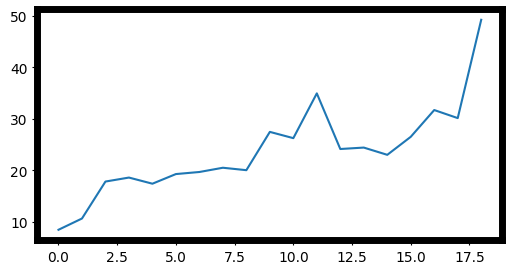

In [74]:
plt.plot(pos_error_raw)

In [69]:
P_x_raw.shape

(19,)

In [70]:
C_matrix_x_raw.shape

(20, 16, 16)

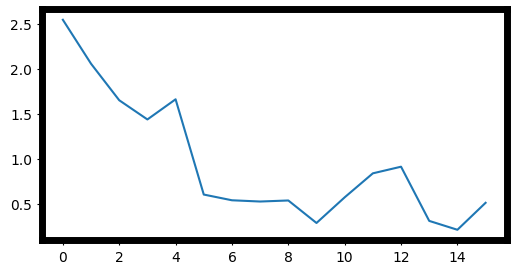

In [61]:
plt.plot(mean_x_raw[fns_plot.get_gene_index('ISL1', data.gene_names),:])

In [42]:
from scipy.interpolate import make_smoothing_spline

N_var = X.shape[2]
bins_x = np.linspace(bins_x_raw[0],bins_x_raw[-1],N_bins_x)
bins_x_sym = (bins_x[1:]+bins_x[:-1])/2
mean_x = np.zeros((N_bins_x,N_var))
var_x = np.zeros((N_bins_x,N_var))
C_matrix_x = np.zeros((N_bins_x,N_var,N_var))
for k in range(0,N_var):
    func_interp_av = make_smoothing_spline(bins_x_raw, mean_x_raw[:,k], lam=lam)
    mean_x[:,k] = func_interp_av(bins_x)
    
    for k2 in range(0,N_var):
        func_interp_covar = make_smoothing_spline(bins_x_raw, C_matrix_x_raw[:,k,k2], lam=lam)
        C_matrix_x[:,k,k2] = func_interp_covar(bins_x)
        
        if k==k2:
            var_x[:,k] = func_interp_covar(bins_x)

dx = bins_x[1:]-bins_x[:-1]
diff_profile = np.diff(mean_x,axis=0)/dx[:,np.newaxis]

C_matrix_x_inv = np.zeros((N_bins_x,N_var,N_var))
for b_x in range(0,N_bins_x):
    C_matrix_x_inv[b_x,:,:] = np.linalg.inv(C_matrix_x[b_x,:,:])

sum_pos_error=0
for i in range(0,N_var):
    for j in range(0,N_var):
        sum_pos_error += diff_profile[:,i]*C_matrix_x_inv[:-1,i,j]*diff_profile[:,j]
pos_error = np.sqrt(1/sum_pos_error)

NameError: name 'lam' is not defined

In [7]:
# Iterate through each condition in the dataset
N_radial_bins_raw = 20
N_radial_bins_smoothed = 50
N_conds = len(conditions)

for it_cond,cond in enumerate(conditions):
    # Load the data from the .pickle file
    if use_scaled:
        f = open(subdirectory_data + '/data_' + cond + "_scaled.pickle",'rb')
        data = pickle.load(f)
        f.close()
    else:
        f = open(subdirectory_data + '/data_' + cond + ".pickle",'rb')
        data = pickle.load(f)
        f.close()

    # Defines a colormap where each color corresponds to a colony
    colors = fns_plot.return_colmaps('replicates',data.N_sys)

    # Choose whether we're using signaling data or marker gene data
    for mode_signals in [0, 1]:
        
        if mode_signals == 1:
            suffix = '_signals'
            data_here = data.signals
            N_var = data.N_signals
            if use_scaled:
                names = ['pERK', 'pSMAD1', 'β-catenin', 'LEF1', 'SMAD2/3', 'YAP', 'pAKT']
                sample_list = ['pSMAD1', 'YAP', 'β-catenin', 'LEF1', 'SMAD2/3', 'pERK', 'pAKT']
            else:
                names = data.signal_names
                sample_list = names
            sig_or_gene = "pSMAD1"
            reg_term = 0.002
            # current_version: reg_term = 0
        else:
            suffix = '_genes'
            data_here = data.genes
            N_var = data.N_genes
            names = data.gene_names
            sample_list = ['GATA3', 'CDX2', 'NANOG', 'TBXT', 'OCT4', 'SOX2'] 
            sig_or_gene = "SOX2"
            reg_term = 0.002
            # current_version: reg_term = 0.00625

        # Define numbers of bins for 1) initial computation of radial profiles and 
        # 2) smoothed interpolated radial profiles
        N_radial_bins_raw = 20
        N_radial_bins_smoothed = 50

        # Iterate through all signals/genes and compute individual positional error
        all_pos_error_single = np.zeros((N_var, N_radial_bins_smoothed-1))
        all_pos_error_single_raw = np.zeros((N_var, N_radial_bins_raw-1))
        all_radial_profiles = np.zeros((N_var, N_radial_bins_smoothed))
        all_variances = np.zeros((N_var, N_radial_bins_smoothed))

        for k in range(0, N_var):
            data_k= data_here[:,:,k][:,:,np.newaxis]
            edge_dist = data.metricdist
            radial_bins_smoothed, avg_radial_profile_smoothed, var_radial_profile_smoothed, pos_error_smoothed ,radial_bins_smoothed_sym, _ = fns_plot.calc_poserror_smooth(data_k, edge_dist, N_radial_bins_raw,data.r_max, reg_term, N_bins_x = N_radial_bins_smoothed)
            all_pos_error_single[k, :] = pos_error_smoothed
            all_radial_profiles[k, :] = avg_radial_profile_smoothed.flatten()
            all_variances[k, :] = var_radial_profile_smoothed.flatten()

        #data_r_max_all[it_cond] = data.r_max
        #radial_bins_smoothed_sym_all_conds[it_cond, :] = radial_bins_smoothed_sym
        #_,_,_, pos_error_smoothed_all_conds[it_cond, :], _,_= fns_plot.calc_poserror_smooth(data_here,data.metricdist, 20, data.r_max, reg_term, N_bins_x = N_radial_bins_smoothed)
        _,_,_,pos_error_comb_smoothed, _,_= fns_plot.calc_poserror_smooth(data_here, data.metricdist, 20, data.r_max, reg_term, N_bins_x = N_radial_bins_smoothed)
        if mode_signals:
            pos_error_comb_smoothed_signal = pos_error_comb_smoothed
            #plt.plot(radial_bins_smoothed_sym,pos_error_comb_smoothed/data.r_max,color='k',lw=6, label = 'all signals')
        else:
            pos_error_comb_smoothed_gene = pos_error_comb_smoothed
            #plt.plot(radial_bins_smoothed_sym,pos_error_comb_smoothed/data.r_max,color='k',lw=6, linestyle='dashed', label = 'all genes')

In [16]:
pos_error_comb_smoothed_gene

array([ 9.69774994, 15.72580783, 14.99147221, 13.0772278 , 12.8499328 ,
       14.53894987, 16.67646784, 17.97643652, 18.42250228, 18.1934551 ,
       18.45943929, 19.04216595, 19.63405761, 20.28015172, 20.79362546,
       22.01225838, 22.26213393, 22.80144691, 25.82630348, 30.27722956,
       31.94928453, 34.96420021, 39.12209869, 34.51105756, 28.38182544,
       26.19169516, 24.84201186, 24.60924994, 24.62844808, 25.47853667,
       27.04587723, 28.53416605, 30.60535968, 31.86692012, 31.83011553,
       31.96335585, 32.42724865, 32.46214057, 33.22573534, 36.21051086,
       41.05112992, 46.10531617, 50.93899061, 54.98602301, 57.18252983,
       58.62359874, 60.92837824, 62.58088855, 62.68012502])

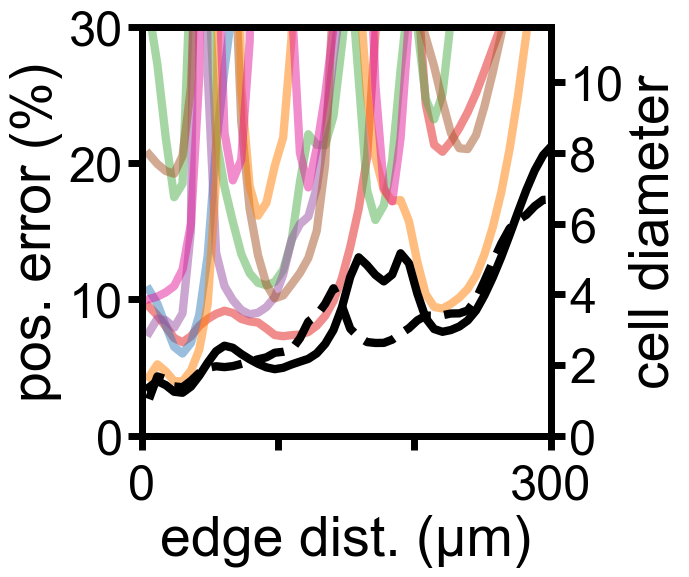

In [5]:
# Plot of Figure 2G (Sample positional errors of other genes + combined positonal error
use_legend = 0

# Compute combined positional error
_,_,_,pos_error_comb_smoothed, _,_= fns_plot.calc_poserror_smooth(data_here,data.metricdist, 20, data.r_max, reg_term, N_bins_x = N_radial_bins_smoothed)
_,_,_,pos_error_comb_raw, _,_= fns_plot.calc_poserror_smooth(data_here,data.metricdist, 20, data.r_max, reg_term, N_bins_x = N_radial_bins_smoothed)

# Create sample list of signals/genes to plot positional error of
sample_indices = [names.index(sample_list[i]) for i in range(len(sample_list))]
colors_sample = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#a65628', '#ff7f00', '#e41a9d']


plt.figure(figsize = (7, 8))            
ax = plt.gca()

# Plot individual positional errors for sample list normalized by maximum radius
for i in range(len(sample_indices)):
    plt.plot(radial_bins_smoothed_sym, all_pos_error_single[sample_indices[i], :]/data.r_max,color=colors_sample[i],lw=6,label= names[sample_indices[i]], alpha=0.5)

# Plot either raw or smooth combined positional error normalized by maximum radius
using_smooth = 1
if using_smooth:
    plt.plot(radial_bins_smoothed_sym,pos_error_comb_smoothed_gene/data.r_max,color='k', linestyle = 'dashed', lw=6, label= 'all markers')
    plt.plot(radial_bins_smoothed_sym,pos_error_comb_smoothed_signal/data.r_max,color='k',lw=6, label= 'all signals')
   
    file_name = subdirectory_plot + "/" + 'poserror' + suffix +'_' + cond + '_total'
else:
    plt.plot(radial_bins_raw_sym, pos_error_comb_raw/data.r_max,color='k',lw=5, label= 'All')
    file_name = subdirectory_plot + "/" + 'intra_' + weight +'_multiple_poserrors_raw_total_err' + suffix + cond

plt.xlabel('edge dist. (μm)', fontsize = label_fontsize, fontweight = weight, family='Arial')
plt.ylabel('pos. error (%)', fontsize = label_fontsize, fontweight = weight, family='Arial')

ax.set_xticks(ticks = np.arange(0, 301, step=100), labels = [0, "", "", 300], fontsize = tick_fontsize ,  family='Arial') 
ax.set_yticks(ticks = np.arange(0, 0.31, step=0.1), labels = np.arange(0, 31, step=10), fontsize = tick_fontsize ,  family='Arial')


# Add second y-axis to link positional error to number of cell diameters
ax2 = ax.twinx()
ax2.set_ylabel("cell diameter", fontsize = label_fontsize, fontweight = weight, family='Arial')
ax2.set_yticks(ticks = np.arange(0, 0.3 + cell_diam/data.r_max, step=2*cell_diam/data.r_max), labels = np.arange(0, 12, step=2) , fontsize = tick_fontsize , family='Arial')

# Set x and y limits
ax.set(xlim = (0,300), ylim = (0, 0.3))
ax2.set(ylim = (0, 0.32))

# Make plot square
ax.set_box_aspect(1)

# Adjust ticks
ax.tick_params(axis = 'y', which = 'major',labelsize=tick_fontsize  , width=5, length=10)
ax.tick_params(axis = 'x', which = 'major',labelsize=tick_fontsize  , width=5, length=10, pad=10)
ax2.tick_params(axis = 'both', which = 'major',labelsize=tick_fontsize  , width=5, length=10)

# Optional settings to add legend
if use_legend:
    legend = ax.legend(prop={'size': 19, 'family': 'Arial'}, ncols = 2, loc="upper center", bbox_to_anchor=(0.5, 1.5), labelspacing=0.2)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.3)
else:
    file_name = file_name + '_no_legend'

plt.tight_layout()
plt.savefig(file_name)


In [15]:
# label_fontsize = 40
# tick_fontsize = 35

# plt.figure(figsize = (7, 6))
# #plt.title(names_title[k], fontsize = 45, pad=20, fontweight = 'bold', family='Arial')
# for i in [0, 1, 2]:
    
    
#     #dist_sym = all_dists_sym[i, :] 
#     #pos_error_profile = all_pos_error_single[k, i, :]
                  
#     ax = plt.gca()
#     # for it in range(0,data.N_sys):
#         #plt.scatter(data.metricdist[it,:],data_here[it,:,k],1,color=colors[it],label=str(it),lw=3)
    
#     plt.plot(radial_bins_smoothed_sym_all_conds[i, :], pos_error_smoothed_all_conds[i, :]/data_r_max_all[i], color=colors[i],  lw=6, label = conditions[i])

# plt.xlabel('edge dist. (μm)', fontsize = label_fontsize, fontweight = weight, family='Arial', color = 'white')
# plt.ylabel('pos. error (%)', fontsize = label_fontsize, fontweight = weight, family='Arial', color = 'white')

# ax.set_xticks(ticks = np.arange(0, 301, step=100), labels = [0, '', '', 300], fontsize = tick_fontsize ,  family='Arial') 
# ax.set_yticks(ticks = np.arange(0, 0.31, step=0.1), labels = np.arange(0, 31, step=10), fontsize = tick_fontsize ,  family='Arial' , color = 'white')


# # Add second y-axis to link positional error to number of cell diameters
# ax2 = ax.twinx()
# ax2.set_ylabel("cell diameter", fontsize = label_fontsize, fontweight = weight, family='Arial')
# ax2.set_yticks(ticks = np.arange(0, 0.3 + cell_diam/data.r_max, step=2*cell_diam/data.r_max), labels = np.arange(0, 12, step=2) , fontsize = tick_fontsize , family='Arial')

# # Set x and y limits
# ax.set(xlim = (0,300), ylim = (0, 0.3))
# ax2.set(ylim = (0, 0.32))

# # Make plot square
# ax.set_box_aspect(1)

# # Adjust ticks
# ax.tick_params(axis = 'y', which = 'major',labelsize=tick_fontsize  , width=5, length=10)
# ax.tick_params(axis = 'x', which = 'major',labelsize=tick_fontsize  , width=5, length=10, pad=10)
# ax2.tick_params(axis = 'both', which = 'major',labelsize=tick_fontsize  , width=5, length=10)

# plt.gca().set_box_aspect(1)


# plt.gca().spines['right'].set_linewidth(0)
# plt.gca().spines['top'].set_linewidth(0)

# use_legend = 0
# if use_legend:
#     legend = ax.legend(prop={'size': 20, 'family': 'Arial', 'weight': 'normal'},loc='lower right')
#     legend.get_frame().set_facecolor('white')
#     legend.get_frame().set_alpha(1)
#     legend_suffix = 'legend'
    
# else:
#     legend_suffix = 'no_legend'
    
# plt.tight_layout()

# plt.savefig(subdirectory_plot + "/" + 'combined_pos_error_total_' + legend_suffix)

In [16]:
# Plot of Figure 2E (intra-colony average of SOX2 profiles)
k = names.index(sig_or_gene)
SOX2_all_colonies = data_here[:,:,k][:,:,np.newaxis]
SOX2_avg_profile = all_radial_profiles[k, :]
SOX2_var_profile = all_variances[k, :]

In [17]:
np.nanpercentile(data_here[:, :, k], 90)


0.7631335909055436

In [45]:
data_metricdist_all = data.metricdist[0, :]
data_here_all = data_here[0,:,k]
color_all = [colors[0] for i in range(len(data_here_all))]

for i in range(1, data.N_sys):
    data_metricdist_all = np.concatenate((data_metricdist_all, data.metricdist[i, :]))
    data_here_all = np.concatenate((data_here_all, data_here[i, :, k]))
    color_all = np.concatenate((color_all, [colors[i] for j in range(len(data_here[i, :, k]))]))

In [46]:
randomized_indices = np.random.permutation(np.arange(len(data_metricdist_all)))

In [47]:
data_metricdist_all_shuffled = data_metricdist_all[randomized_indices]
data_here_all_shuffled = data_here_all[randomized_indices]
color_all_shuffled = color_all[randomized_indices, :]

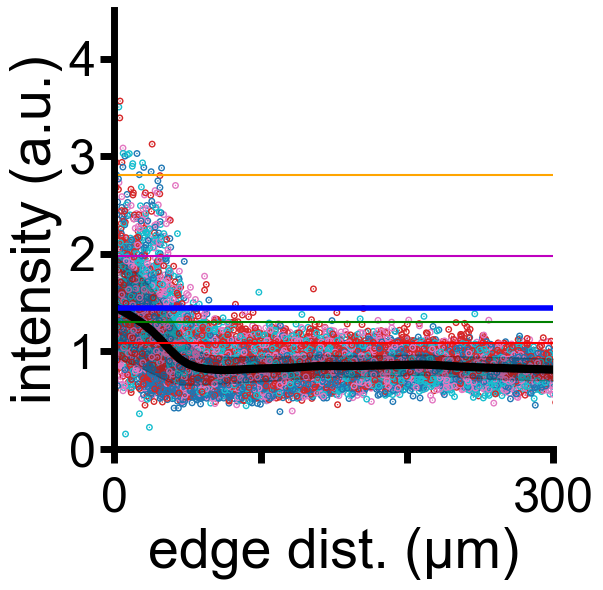

In [48]:
plt.figure(figsize = (7, 6))              
ax = plt.gca()
# Plot all data points for SOX2 + average SOX2 profile across the data

plt.scatter(data_metricdist_all_shuffled, data_here_all_shuffled, 1,color= color_all_shuffled,lw=4)
plt.plot(radial_bins_smoothed, SOX2_avg_profile,'-k',lw=6)


# Add gray error bar
plt.fill_between(radial_bins_smoothed, SOX2_avg_profile-np.sqrt(SOX2_var_profile), SOX2_avg_profile+np.sqrt(SOX2_var_profile),color='k',alpha=0.2)
ax.set_xticks(ticks = np.arange(0, 301, step=100), labels = [0, "", "", 300], fontsize=tick_fontsize , fontweight = weight, family='Arial') 
#ax.set_yticks(ticks = np.arange(0, 1.6, step=1), labels = np.arange(0, 1.6, step=0.5), fontsize = tick_fontsize, fontweight = weight, family='Arial')
ax.set_yticks(ticks = np.arange(0, 6, step=1), labels = np.arange(0, 6, step=1), fontsize = tick_fontsize, fontweight = weight, family='Arial')

# x and y labels
plt.xlabel('edge dist. (μm)', fontsize = label_fontsize, fontweight = weight, family='Arial')
plt.ylabel('intensity (a.u.)', fontsize = label_fontsize,fontweight = weight,  family='Arial')

# Set x and y limits
ax.set(xlim = (0,300), ylim = (0, 4.5))

plt.axhline(np.nanpercentile(SOX2_avg_profile, 100), color = 'b', linewidth = 4)
plt.axhline(np.nanpercentile(data_here_all_shuffled, 90), color = 'r')
plt.axhline(np.nanpercentile(data_here_all_shuffled, 95), color = 'g')
plt.axhline(np.nanpercentile(data_here_all_shuffled, 99), color = 'm')
plt.axhline(np.nanpercentile(data_here_all_shuffled, 99.9), color = 'orange')

# Make plot square
plt.gca().set_box_aspect(1)


# Make right and top bounding boxes invisible
plt.gca().spines['right'].set_linewidth(0)
plt.gca().spines['top'].set_linewidth(0)

# Adjust ticks
plt.gca().tick_params(axis='both', which='major', width=5, length=10)
ax.tick_params(axis = 'y', which = 'major',labelsize=tick_fontsize , width=5, length=10)
ax.tick_params(axis = 'x', which = 'major',labelsize=tick_fontsize , width=5, length=10, pad=10)

plt.tight_layout()
#plt.savefig(subdirectory_plot + "/" + 'radialprofile' + suffix +'_' + cond + '_' + sig_or_gene)

In [25]:
data_here_all_shuffled

array([0.72353643, 0.86118232, 0.80581934, ...,        nan,        nan,
       0.87110961])

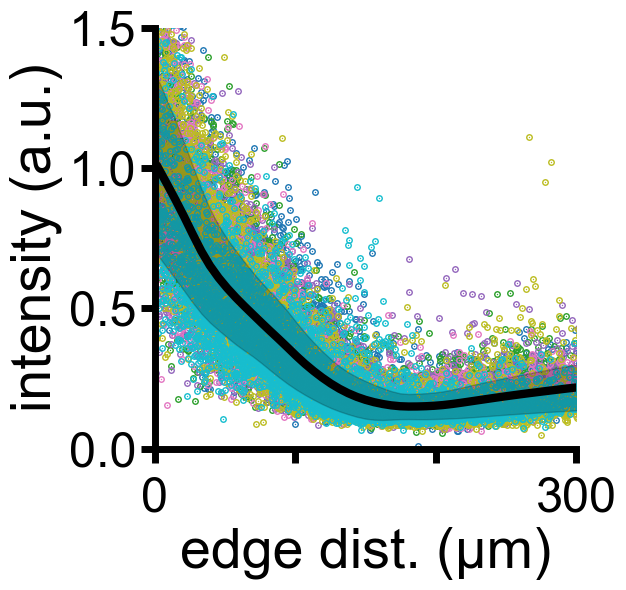

In [78]:
plt.figure(figsize = (7, 6))              
ax = plt.gca()
# Plot all data points for SOX2 + average SOX2 profile across the data
for it in range(0,data.N_sys):
    plt.scatter(data.metricdist[it, :], data_here[it,:,k],1,color=colors[it],label=str(it),lw=4)
plt.plot(radial_bins_smoothed, SOX2_avg_profile,'-k',lw=6)


# Add gray error bar
plt.fill_between(radial_bins_smoothed, SOX2_avg_profile-np.sqrt(SOX2_var_profile), SOX2_avg_profile+np.sqrt(SOX2_var_profile),color='k',alpha=0.2)
ax.set_xticks(ticks = np.arange(0, 301, step=100), labels = [0, "", "", 300], fontsize=tick_fontsize , fontweight = weight, family='Arial') 
ax.set_yticks(ticks = np.arange(0, 1.6, step=0.5), labels = np.arange(0, 1.6, step=0.5), fontsize = tick_fontsize, fontweight = weight, family='Arial')

# x and y labels
plt.xlabel('edge dist. (μm)', fontsize = label_fontsize, fontweight = weight, family='Arial')
plt.ylabel('intensity (a.u.)', fontsize = label_fontsize,fontweight = weight,  family='Arial')

# Set x and y limits
ax.set(xlim = (0,300), ylim = (0, 1.5))


# Make plot square
plt.gca().set_box_aspect(1)


# Make right and top bounding boxes invisible
plt.gca().spines['right'].set_linewidth(0)
plt.gca().spines['top'].set_linewidth(0)

# Adjust ticks
plt.gca().tick_params(axis='both', which='major', width=5, length=10)
ax.tick_params(axis = 'y', which = 'major',labelsize=tick_fontsize , width=5, length=10)
ax.tick_params(axis = 'x', which = 'major',labelsize=tick_fontsize , width=5, length=10, pad=10)

plt.tight_layout()
plt.savefig(subdirectory_plot + "/" + 'radialprofile' + suffix +'_' + cond + '_' + sig_or_gene)

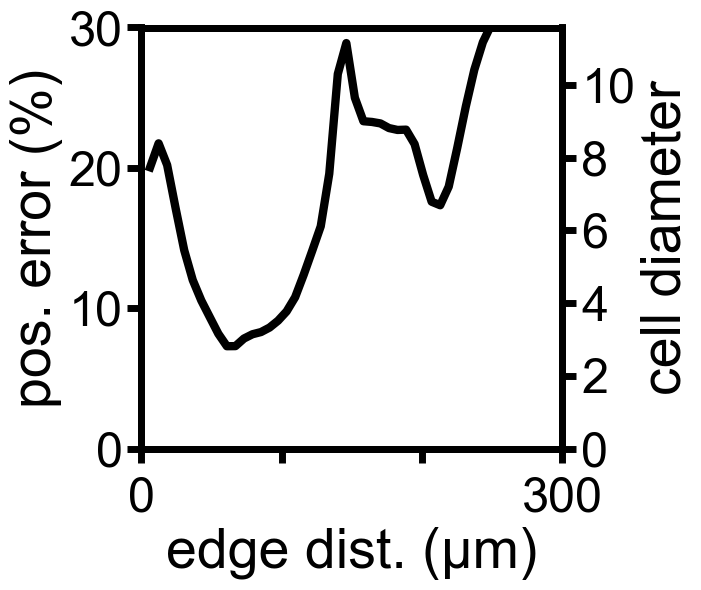

In [91]:
# Plot of Figure 2F (intra-positional error of SOX2 + S0X2 pos. error of individual
# colonies)

SOX2_intra_pos_error = all_pos_error_single[k, :]

plt.figure(figsize = (7, 6))
ax = plt.gca()

# Plot S0X2 positional error normalized by maximum radius for each individual colonies
for it in range(0,data.N_sys):
    data_SOX2_it = data_here[it,:,k][np.newaxis,:,np.newaxis]
    edge_dist_it = data.metricdist[it,:][np.newaxis,:]
    _,_,_,pos_error_it,radial_bins_smoothed_sym,_ = fns_plot.calc_poserror_smooth(data_SOX2_it,edge_dist_it,N_radial_bins_raw,data.r_max, reg_term, N_bins_x = N_radial_bins_smoothed)
    #plt.plot(radial_bins_smoothed_sym,pos_error_it/data.r_max,color=colors[it],lw=6,alpha=0.5)
    
# Plot S0X2 positional error normalized by maximum radius
plt.plot(radial_bins_smoothed_sym, SOX2_intra_pos_error/data.r_max,color='k',lw=6)

# x and y labels
plt.xlabel('edge dist. (μm)', fontsize = label_fontsize, fontweight = weight, family='Arial')
plt.ylabel('pos. error (%)', fontsize = label_fontsize, fontweight = weight, family='Arial')

ax.set_xticks(ticks = np.arange(0, 301, step=100), labels = [0, "", "", 300], fontsize = tick_fontsize ,  family='Arial') 
ax.set_yticks(ticks = np.arange(0, 0.31, step=0.1), labels = np.arange(0, 31, step=10), fontsize = tick_fontsize ,  family='Arial')


# Add second y-axis to link positional error to number of cell diameters
ax2 = ax.twinx()
ax2.set_ylabel("cell diameter", fontsize = label_fontsize, fontweight = weight, family='Arial')
ax2.set_yticks(ticks = np.arange(0, 0.3 + cell_diam/data.r_max, step=2*cell_diam/data.r_max), labels = np.arange(0, 12, step=2) , fontsize = tick_fontsize , family='Arial')

# Set x and y limits
ax.set(xlim = (0,300), ylim = (0, 0.3))
ax2.set(ylim = (0, 0.32))

# Make plot square
ax.set_box_aspect(1)

# Adjust ticks
ax.tick_params(axis = 'y', which = 'major',labelsize=tick_fontsize  , width=5, length=10)
ax.tick_params(axis = 'x', which = 'major',labelsize=tick_fontsize  , width=5, length=10, pad=10)
ax2.tick_params(axis = 'both', which = 'major',labelsize=tick_fontsize  , width=5, length=10)


plt.tight_layout()
plt.savefig(subdirectory_plot + "/" + 'poserror' + suffix +'_' + cond + '_' + sig_or_gene)

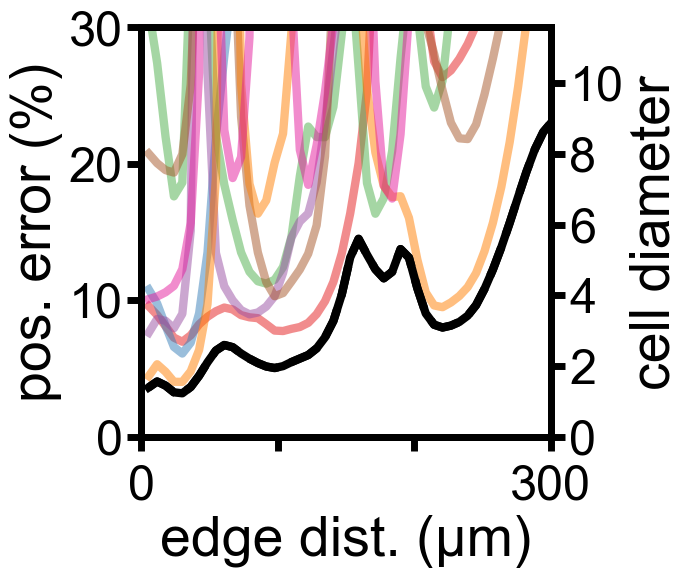